<a href="https://colab.research.google.com/github/DouglaasPH/DouglaasPH/blob/main/experimento_ia_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  # 1. Criar pasta para o dataset
!mkdir -p /content/dataset

# 2. Baixar o arquivo zip utilizando o seu comando curl
!curl -L -o /content/dataset/covid19-radiography-database.zip https://www.kaggle.com/api/v1/datasets/download/tawsifurrahman/covid19-radiography-database

# 3. Descompactar silenciosamente na pasta de destino
!unzip -q /content/dataset/covid19-radiography-database.zip -d /content/dataset

# 4. Verificar o conteúdo extraído para garantir que os caminhos estão corretos
!ls /content/dataset/COVID-19_Radiography_Dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  778M  100  778M    0     0   101M      0  0:00:07  0:00:07 --:--:--  107M
 COVID			      Normal.metadata.xlsx
 COVID.metadata.xlsx	      README.md.txt
 Lung_Opacity		     'Viral Pneumonia'
 Lung_Opacity.metadata.xlsx  'Viral Pneumonia.metadata.xlsx'
 Normal


In [ ]:
# Importar as dependencias necessárias
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, datasets, Sequential
from tensorflow.keras.layers import Conv2D, Activation, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf

data_dir = "/content/dataset/COVID-19_Radiography_Dataset"

# 1. Carrega o dataset bruto
ds_bruto = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    shuffle=False,
    image_size=(224, 224),
    batch_size=32
)

# salvamos os nomes das classes diretamente do dataset bruto
class_names = ds_bruto.class_names
num_classes = len(class_names)

print(f"classes encontradas: {class_names}")

Found 42330 files belonging to 4 classes.
classes encontradas: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [ ]:
# quantidade de imagens por classe
IMAGENS_POR_CLASSE = 256

# separar o dataset por classes
datasets_por_classe = []

# filtra e pega 1000 imagens de cada classe
for i, class_name in enumerate(class_names):
    ds_classe = ds_bruto.unbatch().filter(lambda x, y: y == i).take(IMAGENS_POR_CLASSE)
    datasets_por_classe.append(ds_classe)

# unir imagens  em uma única variável
balanced_ds = datasets_por_classe[0]
for ds_classe in datasets_por_classe[1:]:
    balanced_ds = balanced_ds.concatenate(ds_classe)

# embaralhar as 4000 imagens
total_imagens_balanceado = len(class_names) * IMAGENS_POR_CLASSE
balanced_ds = balanced_ds.shuffle(buffer_size=total_imagens_balanceado, seed=123)

# divisão 80/20
num_train = int(total_imagens_balanceado * 0.8)
train_ds_bruto = balanced_ds.take(num_train)
test_ds_bruto = balanced_ds.skip(num_train)

# normaliza e recria os batches de treino e validação
train_ds = train_ds_bruto.map(lambda x, y: (x / 255.0, y)).cache().batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds_bruto.map(lambda x, y: (x / 255.0, y)).cache().batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"\nDataset balanceado e cortado com sucesso!")
print(f"Total de imagens no treino: {num_train}")
print(f"Total de imagens na validação: {total_imagens_balanceado - num_train}")


Dataset balanceado e cortado com sucesso!
Total de imagens no treino: 819
Total de imagens na validação: 205


In [ ]:
# Criação da rede neural
# O shape das imagens é sempre 224x224 pixels com 3 canais de cor (RGB)
def CNN_classification_model(input_size =(224, 224, 3)):
    model = Sequential()
    # Camada de Data Augmentation Clinicamente Ajustada
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
    ])

    # aplicar o data_augmentation antes da primeira camada
    model.add(layers.Input(shape=input_size))
    model.add(data_augmentation)


    # primeiro bloco 32 filtros
    model.add(Conv2D(32, (3,3)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2,2), strides=1))

    # segundo bloco 64 filtros
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(64, (3,3)))
    model.add(Activation('relu'))
    model.add(MaxPool2D(pool_size=(2,2)))

    # terceiro bloco 128 filtros
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPool2D(pool_size=(2,2)))

    # quarto bloco 256 filtros
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    # quinto bloco 512 filtros
    model.add(Conv2D(512, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(512, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    # camada diretamente conectada (flatten/dense) e de saída
    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes))
    model.add(Activation('softmax'))

    # otimizador adam com taxa padrão de aprendizagem
    opt = keras.optimizers.Adam(learning_rate=0.0001)

    # cria o modelo usa crossentropia e acurácia para avaliar
    model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    return model

In [ ]:
#cria modelo da CNN
model=CNN_classification_model()

In [ ]:
#mostra como a CNN ficou
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 221, 221, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 221, 221, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 221, 221, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 219, 219, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 219, 219, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 109, 109, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 109, 109, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 54, 54, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 54, 54, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 54, 54, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 27, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 27, 27, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 27, 27, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 27, 27, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,779,332 (60.19 MB)

 Trainable params: 15,779,268 (60.19 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# Carrega o avaliador
from tensorflow.keras.callbacks import ModelCheckpoint

model_name = "final_covid.keras"

model_checkpoint = ModelCheckpoint(
    model_name,
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)

In [ ]:
# Treina o modelo adaptado para o Dataset de COVID-19
history = model.fit(
    train_ds,                         # Passa o pipeline de treino (substitui x_train e y_train)
    validation_data=test_ds,          # Passa o pipeline de validação (substitui x_val e y_val)
    epochs=500,
    callbacks=[model_checkpoint]
)

Epoch 1/500
     26/Unknown 119s 677ms/step - accuracy: 0.3849 - loss: 1.2879

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 1.37057, saving model to final_covid.keras

Epoch 1: finished saving model to final_covid.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.4469 - loss: 1.2001 - val_accuracy: 0.2976 - val_loss: 1.3706
Epoch 2/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.5325 - loss: 1.0197
Epoch 2: val_loss improved from 1.37057 to 1.31426, saving model to final_covid.keras

Epoch 2: finished saving model to final_covid.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 483ms/step - accuracy: 0.5360 - loss: 1.0169 - val_accuracy: 0.4244 - val_loss: 1.3143
Epoch 3/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.5814 - loss: 0.9493
Epoch 3: val_loss improved from 1.31426 to 1.21320, saving model to final_covid.keras

Epoch 3: finished saving model to final_covid.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 495ms/step - accuracy: 0.5861 - loss: 0.9403 - val_accuracy: 0.5854 - val_loss: 1.2132
Epoch 4/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accu

In [ ]:
score = model.evaluate(test_ds, verbose=1)
print('Perda do teste:', score[0])
print('Acurácia do teste:', score[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9659 - loss: 0.2225
Perda do teste: 0.22245728969573975
Acurácia do teste: 0.9658536314964294


In [ ]:
new_model = CNN_classification_model()
new_model.load_weights("final_covid.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Pega o primeiro lote do dataset (se seu batch_size for 32, virão 32 imagens)
for images, labels in test_ds.take(1):
    predictions = new_model.predict(images)
    print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
[[9.9999976e-01 2.7107177e-07 8.0186107e-09 1.3491440e-12]
 [1.0063458e-11 8.1726753e-08 1.2405743e-05 9.9998748e-01]
 [9.8614329e-01 1.3593048e-02 2.6366432e-04 1.6495333e-08]
 [9.8053610e-01 1.9455539e-02 8.2488295e-06 1.8968906e-08]
 [1.0000000e+00 2.1993951e-09 2.9006775e-13 2.6965894e-14]
 [9.9233633e-01 6.8066660e-03 8.5574307e-04 1.2803923e-06]
 [9.3536031e-01 1.5809078e-02 4.8830505e-02 7.3807058e-08]
 [2.8699806e-03 5.0811018e-03 9.9204892e-01 7.0807169e-09]
 [1.0880765e-23 9.5948249e-13 9.7382958e-22 1.0000000e+00]
 [1.0000000e+00 3.6623615e-13 8.2659370e-14 1.1797116e-11]
 [1.5039860e-23 4.6229279e-16 2.4815869e-21 1.0000000e+00]
 [2.3905776e-25 5.9495301e-18 2.2501863e-21 1.0000000e+00]
 [5.0369522e-06 5.3110839e-06 9.9998963e-01 1.1673918e-13]
 [7.7744143e-04 5.9047079e-01 4.0875176e-01 5.1765529e-08]
 [1.2269987e-22 3.7052986e-17 3.1935165e-20 1.0000000e+00]
 [3.8663231e-04 9.9627388e-01 3.3367397e-03 2.8629991e-06]
 [5.9398985e-16 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


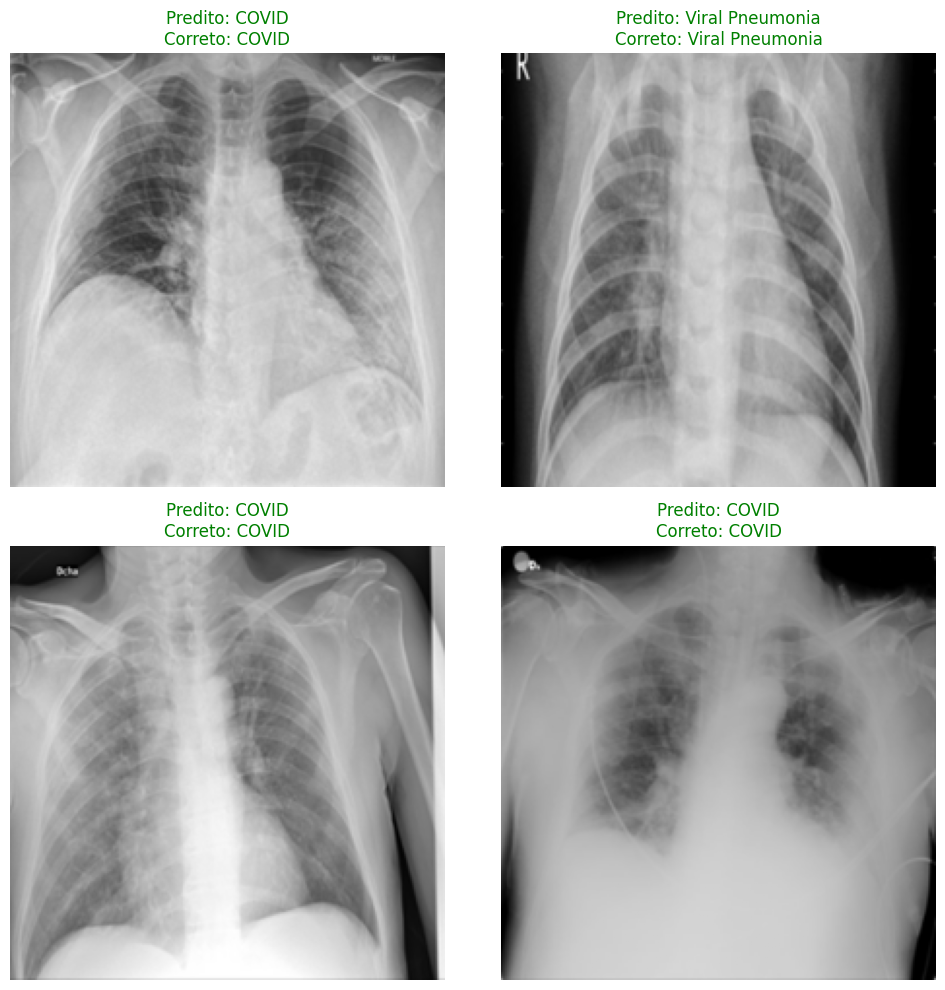

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Mapeia automaticamente as classes em texto usando o seu ds_bruto original
class_names = ds_bruto.class_names  # ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# 2. Desempacota apenas o primeiro lote (batch) do seu dataset de teste real
for images_batch, labels_batch in test_ds.take(1):

    # Convertemos o lote para estruturas que o numpy e o matplotlib entendem
    x_test_batch = images_batch.numpy()
    y_test_batch = labels_batch.numpy()

    # 3. Faz a predição das 4 primeiras imagens desse lote
    raw_predictions = new_model.predict(x_test_batch[0:4])
    pred_list = np.argmax(raw_predictions, axis=-1)

    # Configura o tamanho da janela das imagens (Grid 2x2)
    plt.figure(figsize=(10, 10))

    # 4. Loop para desenhar o grid
    for i in range(0, 4):
        plt.subplot(2, 2, i + 1)

        # Plota a imagem correspondente
        plt.imshow(x_test_batch[i])

        # Traduz os índices numéricos para os nomes reais das classes
        classe_predita = class_names[pred_list[i]]
        classe_correta = class_names[int(y_test_batch[i])]

        # Define a cor do título: verde se o modelo acertou, vermelho se errou
        cor_titulo = 'green' if classe_predita == classe_correta else 'red'

        plt.title(f"Predito: {classe_predita}\nCorreto: {classe_correta}", color=cor_titulo, fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    break # Garante que o loop pare após processar as primeiras 4 imagens

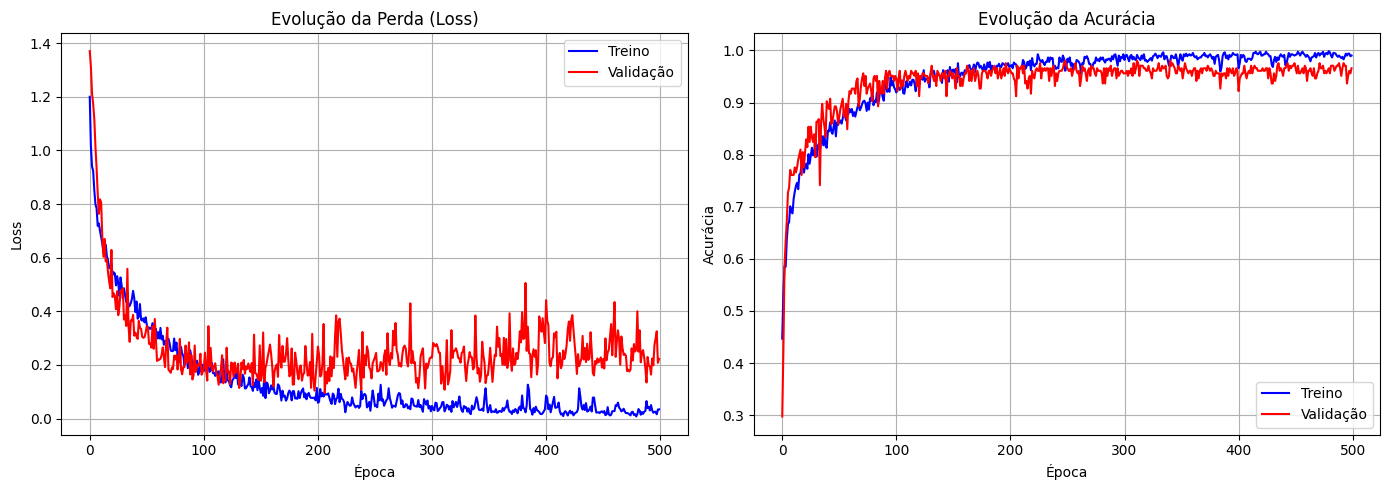

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino', color='blue')
plt.plot(history.history['val_loss'], label='Validação', color='red')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino', color='blue')
plt.plot(history.history['val_accuracy'], label='Validação', color='red')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-learn seaborn

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    cohen_kappa_score, roc_auc_score
)

In [ ]:
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = new_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

y_pred = np.argmax(y_pred_probs, axis=-1)

print(classification_report(y_true, y_pred, target_names=class_names))

                 precision    recall  f1-score   support

          COVID       0.95      0.98      0.97        61
   Lung_Opacity       0.98      0.91      0.94        44
         Normal       0.96      1.00      0.98        44
Viral Pneumonia       1.00      0.98      0.99        56

       accuracy                           0.97       205
      macro avg       0.97      0.97      0.97       205
   weighted avg       0.97      0.97      0.97       205



In [ ]:
# cohen kappa
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

Cohen's Kappa Score: 0.9607


In [ ]:
# auc-roc (One-vs-Rest)
auc_roc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
print(f"AUC-ROC Score (Macro): {auc_roc:.4f}\n")

AUC-ROC Score (Macro): 0.9972



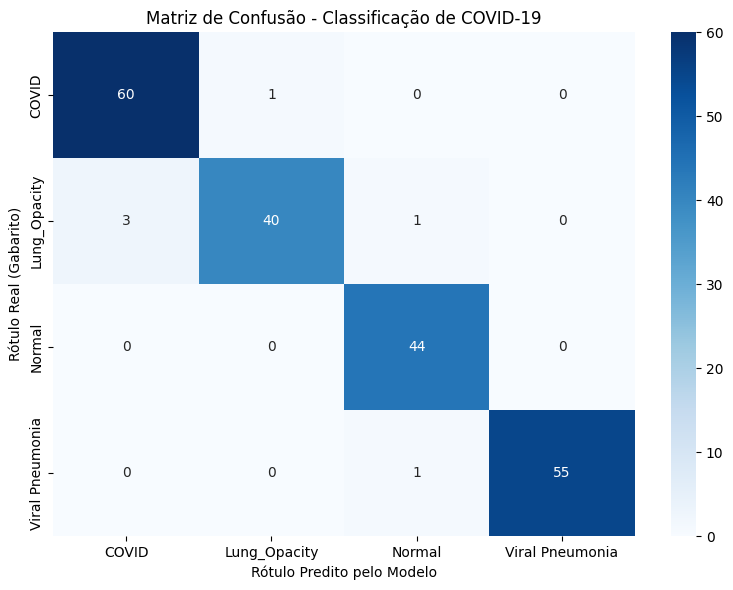

In [ ]:
# matriz de confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title('Matriz de Confusão - Classificação de COVID-19')
plt.ylabel('Rótulo Real (Gabarito)')
plt.xlabel('Rótulo Predito pelo Modelo')
plt.tight_layout()
plt.show()